In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Leitura

In [69]:
df = pd.read_csv('energy_consumption.csv')

print(df)

               Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0    2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1    2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2    2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3    2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4    2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   
..                   ...          ...        ...            ...        ...   
995  2022-02-11 11:00:00    28.619382  48.850160    1080.087000          5   
996  2022-02-11 12:00:00    23.836647  47.256435    1705.235156          4   
997  2022-02-11 13:00:00    23.005340  48.720501    1320.285281          6   
998  2022-02-11 14:00:00    25.138365  31.306459    1309.079719          3   
999  2022-02-11 15:00:00    23.051165  42.615421    1018.140606          6   

    HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday

### Criando dataframe

- podia usar index = 

In [70]:
df = df[['Temperature', 'Humidity', 'Occupancy', 'DayOfWeek', 'Holiday', 'EnergyConsumption']]

print(df.to_string())

     Temperature   Humidity  Occupancy  DayOfWeek Holiday  EnergyConsumption
0      25.139433  43.431581          5     Monday      No          75.364373
1      27.731651  54.225919          1   Saturday      No          83.401855
2      28.704277  58.907658          2     Sunday      No          78.270888
3      20.080469  50.371637          1  Wednesday      No          56.519850
4      23.097359  51.401421          9     Friday      No          70.811732
5      29.576037  36.824263          6     Sunday     Yes          84.321885
6      25.131167  35.709622          6     Friday     Yes          76.165791
7      23.182844  31.679920          8   Thursday     Yes          74.131906
8      25.391999  46.399364          6     Sunday      No          78.206236
9      22.212549  32.418464          1    Tuesday      No          77.992214
10     28.064814  36.451472          2     Monday     Yes          82.274434
11     23.422546  30.527342          6   Thursday     Yes          73.278670

# Filtering

In [100]:
print(df['Temperature'].mean())
# print(df[df['Temperature'] >= 24.982026291058794].count()) # .value_counts()
print(df['Humidity'].mean())
# print(df[df['Humidity'] >= 45.39541178594965].count())
print(df[df['Holiday'] == 'Yes'].count())
print(df['Temperature'].max())
print(df['Occupancy'].max())

24.982026291058794
45.39541178594965
Temperature          467
Humidity             467
Occupancy            467
DayOfWeek            467
Holiday              467
EnergyConsumption    467
dtype: int64
29.998670840983927
9


# Groupby
Group rows by a common feature

In [74]:
hott_day = df[df['Temperature'] >= 24.982026291058794]
wett_day = df[df['Humidity'] > 45.39541178594965]

In [75]:
print(hott_day)
print(wett_day)

     Temperature   Humidity  Occupancy DayOfWeek Holiday  EnergyConsumption
0      25.139433  43.431581          5    Monday      No          75.364373
1      27.731651  54.225919          1  Saturday      No          83.401855
2      28.704277  58.907658          2    Sunday      No          78.270888
5      29.576037  36.824263          6    Sunday     Yes          84.321885
6      25.131167  35.709622          6    Friday     Yes          76.165791
..           ...        ...        ...       ...     ...                ...
992    27.621883  52.275173          8  Saturday     Yes          93.639644
993    28.732844  44.170648          9  Saturday      No          83.299462
994    26.656889  54.163668          8    Friday      No          89.964064
995    28.619382  48.850160          5  Saturday      No          82.306692
998    25.138365  31.306459          3  Thursday     Yes          76.950389

[476 rows x 6 columns]
     Temperature   Humidity  Occupancy  DayOfWeek Holiday  Energ

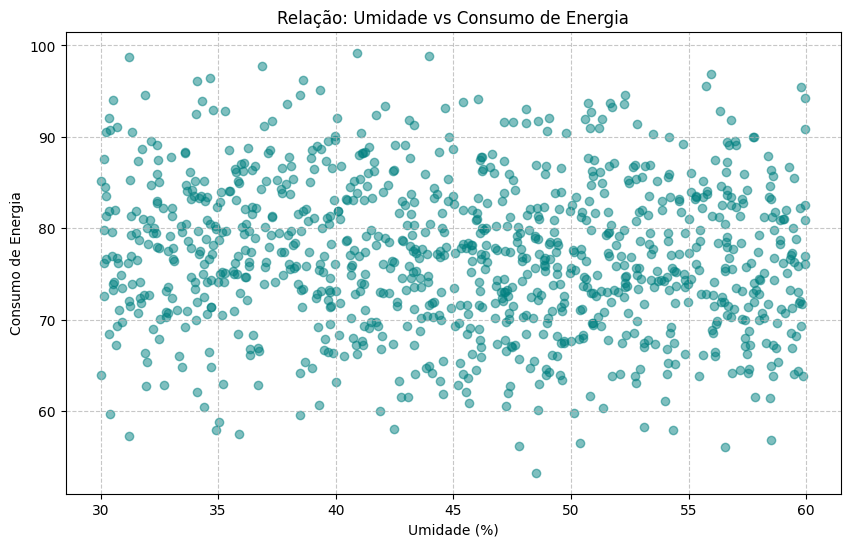

In [84]:
plt.figure(figsize=(10, 6))
# Usamos scatter em vez de plot
plt.scatter(df['Humidity'], df['EnergyConsumption'], alpha=0.5, color='teal')

plt.title('Relação: Umidade vs Consumo de Energia')
plt.xlabel('Umidade (%)')
plt.ylabel('Consumo de Energia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

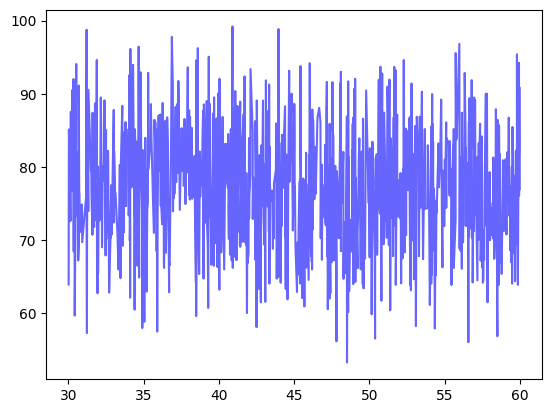

In [85]:
df_sorted_humidity = df.sort_values(by='Humidity')

plt.plot(df_sorted_humidity['Humidity'], df_sorted_humidity['EnergyConsumption'], color='blue', alpha=0.6)
plt.show()

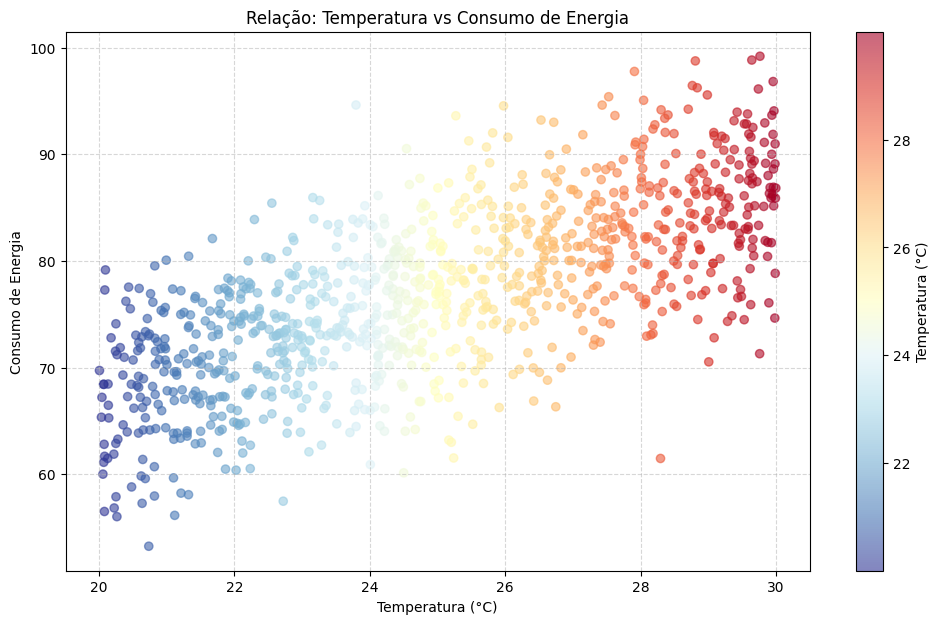

In [87]:


plt.figure(figsize=(12, 7))

# O segredo está aqui:
# c=df['Temperature'] -> as cores seguem os valores da temperatura
# cmap='RdYlBu_r' -> paleta que vai do azul (frio) ao vermelho (quente)
scatter = plt.scatter(df['Temperature'], df['EnergyConsumption'], 
                      c=df['Temperature'], 
                      cmap='RdYlBu_r', 
                      alpha=0.6)

# Adiciona uma barra lateral para mostrar a escala da temperatura
plt.colorbar(scatter, label='Temperatura (°C)')

plt.title('Relação: Temperatura vs Consumo de Energia')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Consumo de Energia')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

   Occupancy  EnergyConsumption
0          0        7343.964341
1          1        6938.867557
2          2        7273.387025
3          3        8199.409395
4          4        7023.075290
5          5        7421.702570
6          6        8173.776104
7          7        7841.114267
8          8        9437.360747
9          9        7403.215573
RangeIndex(start=0, stop=10, step=1)
[[0.00000000e+00 7.34396434e+03]
 [1.00000000e+00 6.93886756e+03]
 [2.00000000e+00 7.27338703e+03]
 [3.00000000e+00 8.19940939e+03]
 [4.00000000e+00 7.02307529e+03]
 [5.00000000e+00 7.42170257e+03]
 [6.00000000e+00 8.17377610e+03]
 [7.00000000e+00 7.84111427e+03]
 [8.00000000e+00 9.43736075e+03]
 [9.00000000e+00 7.40321557e+03]]


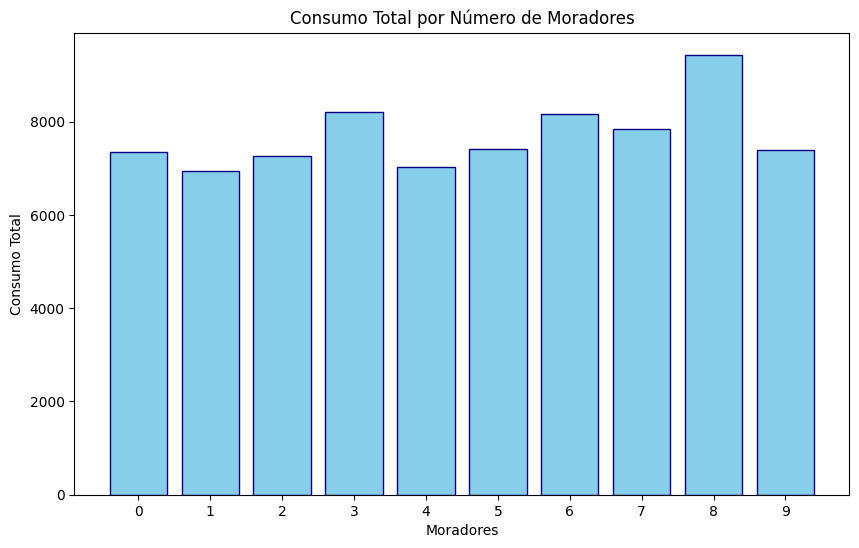

In [110]:
consume_per_occupancy = df.groupby('Occupancy')['EnergyConsumption'].sum().reset_index()
print(consume_per_occupancy)
print(consume_per_occupancy.index)
print(consume_per_occupancy.values)

plt.figure(figsize=(10, 6))

plt.bar(
    consume_per_occupancy['Occupancy'],
    consume_per_occupancy['EnergyConsumption'],
    color='skyblue',
    edgecolor='navy'
)

plt.title('Consumo Total por Número de Moradores')
plt.xlabel('Moradores')
plt.ylabel('Consumo Total')
plt.xticks(consume_per_occupancy['Occupancy'])
plt.show()